# Experiment 3: Class Distribution Analysis

## Aim
To analyze and visualize the distribution of images across different plant disease classes using pandas and matplotlib.

## Theory
Class distribution analysis reveals potential imbalances in the dataset. An imbalanced dataset (where some classes have significantly more samples than others) can:
- Bias the model toward frequently occurring classes
- Result in poor performance on minority classes
- Require specialized loss functions or sampling strategies

Visualizing class distribution helps in understanding these characteristics and planning appropriate mitigation strategies.

CLASS DISTRIBUTION ANALYSIS

📊 CLASS DISTRIBUTION TABLE:
                               Class  Image Count
                    Corn leaf blight          179
           Tomato Septoria leaf spot          140
          Squash Powdery mildew leaf          124
                      Raspberry leaf          112
            Potato leaf early blight          108
                      Corn rust leaf          106
                      Blueberry leaf          104
                          Peach leaf          102
             Tomato leaf late blight          101
          Tomato leaf bacterial spot          101
             Potato leaf late blight           97
                     Strawberry leaf           88
                    Tomato mold leaf           85
                     Apple Scab Leaf           83
                          Apple leaf           82
            Tomato Early blight leaf           79
                     Apple rust leaf           78
            Tomato leaf yellow virus       

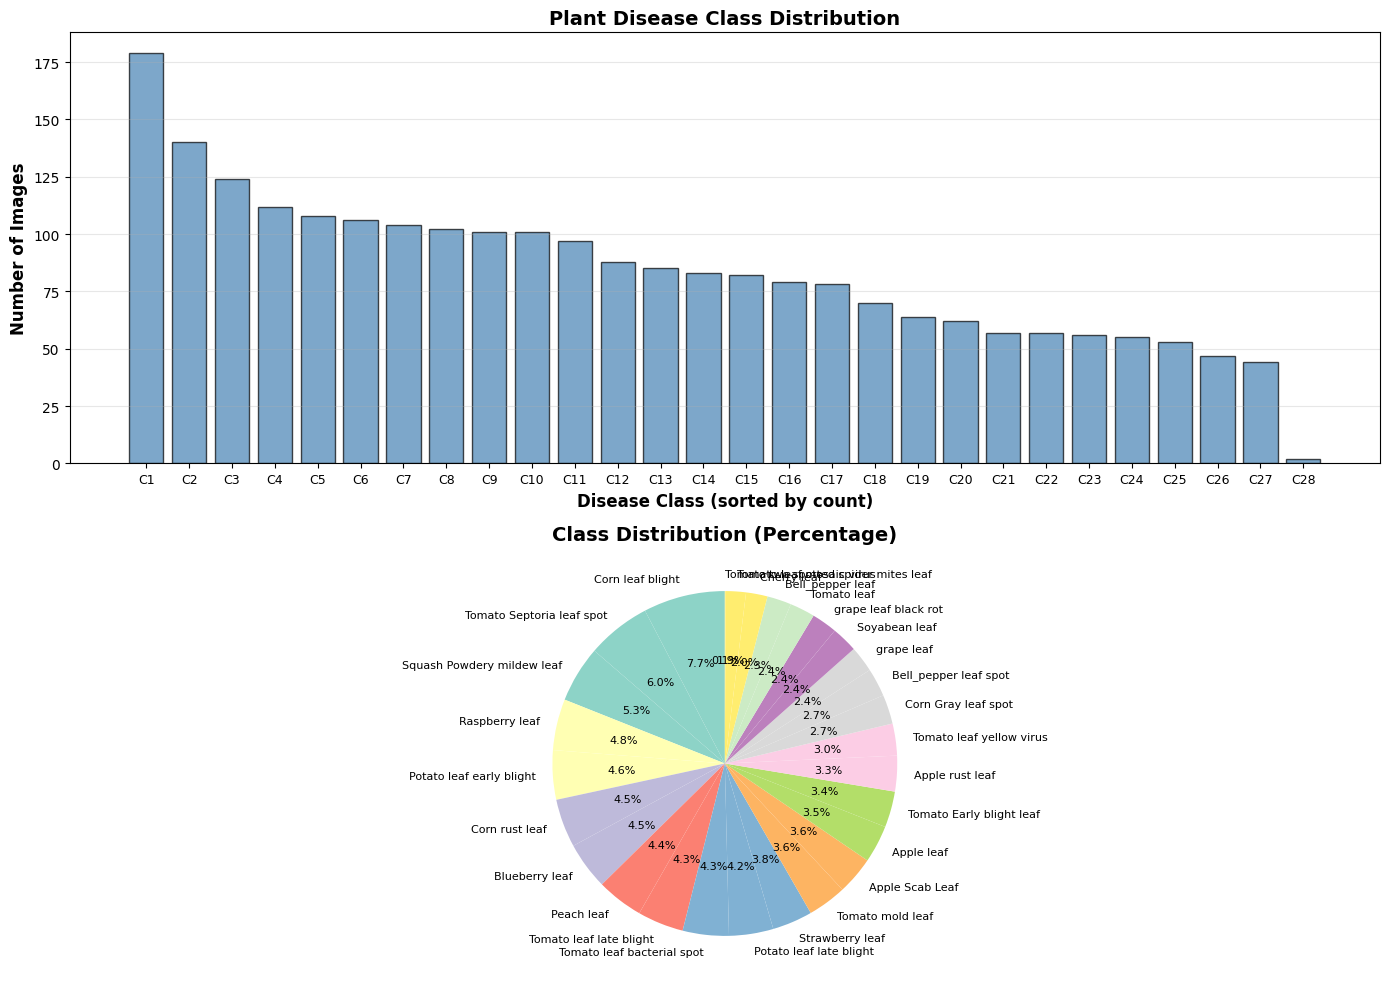


✓ Visualization saved as 'exp3_distribution.png'


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset path
dataset_root = "/Users/nishant/Documents/vscode/plant_disease_detection/data/PlantDoc-Dataset-master"
train_path = os.path.join(dataset_root, "train")

print("="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)

# Collect class statistics
class_data = []
class_dirs = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

for class_name in class_dirs:
    class_path = os.path.join(train_path, class_name)
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    class_data.append({
        'Class': class_name,
        'Image Count': len(images)
    })

# Create DataFrame
df = pd.DataFrame(class_data)
df = df.sort_values('Image Count', ascending=False).reset_index(drop=True)

print("\n📊 CLASS DISTRIBUTION TABLE:")
print(df.to_string(index=False))

print("\n📈 STATISTICS:")
print(f"Total Classes: {len(df)}")
print(f"Total Images: {df['Image Count'].sum()}")
print(f"Mean Images/Class: {df['Image Count'].mean():.2f}")
print(f"Median Images/Class: {df['Image Count'].median():.2f}")
print(f"Min Images/Class: {df['Image Count'].min()}")
print(f"Max Images/Class: {df['Image Count'].max()}")
print(f"Std Dev: {df['Image Count'].std():.2f}")

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Bar chart
ax1 = axes[0]
ax1.bar(range(len(df)), df['Image Count'], color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Disease Class (sorted by count)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax1.set_title('Plant Disease Class Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels([f'C{i+1}' for i in range(len(df))], fontsize=9)

# Pie chart
ax2 = axes[1]
colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
wedges, texts, autotexts = ax2.pie(df['Image Count'], labels=df['Class'], autopct='%1.1f%%',
                                     colors=colors, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
plt.setp(autotexts, size=8)
plt.setp(texts, size=8)

plt.tight_layout()
plt.savefig('/Users/nishant/Documents/vscode/plant_disease_detection/experiment/exp3_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'exp3_distribution.png'")
print("="*70)

## Result
A comprehensive analysis of class distribution was performed using pandas. The dataset shows varying numbers of images across different disease classes. A DataFrame was created containing all class names and their corresponding image counts, sorted in descending order. Two visualizations (bar chart and pie chart) clearly show the distribution pattern across all classes.

## Conclusion
The class distribution analysis reveals the dataset's composition. Understanding this distribution is critical for model training, as it helps identify potential class imbalance issues that may require techniques like weighted loss functions or oversampling strategies.